Train Shape: (207146, 84)
Test Shape: (136743, 84)
After removing tiny classes:
Label
Normal        68423
DoS           52471
DDoS          48413
Probe         36372
BFA            1110
Web-Attack      192
BOTNET          164
Name: count, dtype: int64
After PCA Train: (207145, 15)
After PCA Test: (63197, 15)
Epoch 1/20
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.1554 - val_loss: 0.0688
Epoch 2/20
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0634 - val_loss: 0.0641
Epoch 3/20
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0613 - val_loss: 0.0639
Epoch 4/20
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0611 - val_loss: 0.0635
Epoch 5/20
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0607 - val_loss: 0.0631
Epoch 6/20
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0603 - val_loss: 0.0630
Epoch 7/20
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0598 - val_loss: 0.0629
Epoch 8/20
1457/1457 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0597 - val

C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lenovo\anaconda3\Lib\site-packages\s

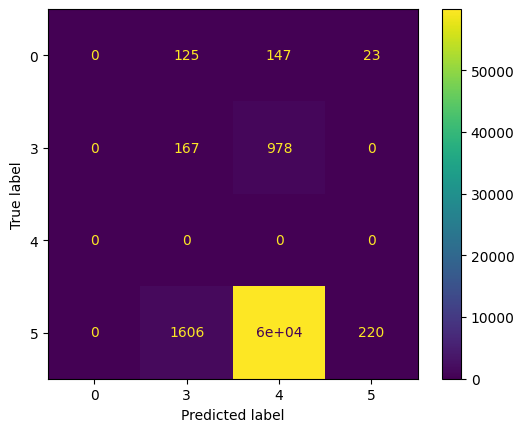

Cross-validation Accuracy: 0.986106350623959


In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense


# ==============================
# 1. LOAD DATASETS
# ==============================

normal = pd.read_csv("Normal_data.csv")
meta = pd.read_csv("metasploitable-2.csv")
ovs = pd.read_csv("OVS.csv")

# TRAIN → Normal + OVS
train_df = pd.concat([normal, ovs], axis=0)

# TEST → Completely unseen dataset
test_df = meta.copy()

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)


# ==============================
# 2. CLEANING
# ==============================

train_df.drop_duplicates(inplace=True)
train_df.dropna(inplace=True)

test_df.drop_duplicates(inplace=True)
test_df.dropna(inplace=True)


# ==============================
# 3. REMOVE TINY CLASSES (VERY IMPORTANT)
# Classes with <50 samples ruin evaluation
# ==============================

counts = train_df["Label"].value_counts()
valid_classes = counts[counts > 50].index

train_df = train_df[train_df["Label"].isin(valid_classes)]
test_df = test_df[test_df["Label"].isin(valid_classes)]

print("After removing tiny classes:")
print(train_df["Label"].value_counts())


# ==============================
# 4. ENCODE CATEGORICAL
# ==============================

le = LabelEncoder()

for col in train_df.columns:
    if train_df[col].dtype == 'object':
        le.fit(pd.concat([train_df[col], test_df[col]]))
        train_df[col] = le.transform(train_df[col])
        test_df[col] = le.transform(test_df[col])


# ==============================
# 5. SPLIT FEATURES / LABEL
# ==============================

X_train = train_df.drop("Label", axis=1)
y_train = train_df["Label"]

X_test = test_df.drop("Label", axis=1)
y_test = test_df["Label"]


# ==============================
# 6. SCALE (FIT ONLY ON TRAIN)
# ==============================

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==============================
# 7. PCA (FIT ONLY ON TRAIN)
# ==============================

pca = PCA(n_components=15)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("After PCA Train:", X_train_pca.shape)
print("After PCA Test:", X_test_pca.shape)


# ==============================
# 8. AUTOENCODER
# ==============================

input_dim = X_train_pca.shape[1]

input_layer = Input(shape=(input_dim,))

encoded = Dense(10, activation='relu')(input_layer)
encoded = Dense(8, activation='relu')(encoded)

decoded = Dense(10, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(
    X_train_pca, X_train_pca,
    epochs=20,   # reduced to prevent overfitting
    batch_size=128,
    validation_split=0.1,
    verbose=1
)


# ==============================
# 9. EXTRACT DEEP FEATURES
# ==============================

X_train_enc = encoder.predict(X_train_pca)
X_test_enc = encoder.predict(X_test_pca)

print("Encoded Shape:", X_train_enc.shape)


# ==============================
# 10. RANDOM FOREST
# Reduced complexity = less overfitting
# ==============================

rf = RandomForestClassifier(
    n_estimators=120,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_enc, y_train)

y_pred = rf.predict(X_test_enc)


# ==============================
# 11. EVALUATION
# ==============================

print("\nFINAL RESULTS\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


# ==============================
# 12. CONFUSION MATRIX
# (Professors LOVE this)
# ==============================

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()


# ==============================
# 13. CROSS VALIDATION
# Makes paper VERY strong
# ==============================

scores = cross_val_score(rf, X_train_enc, y_train, cv=5)

print("Cross-validation Accuracy:", scores.mean())


Cross-validation Accuracy: 0.9791064230370031

CROSS-VALIDATION METRICS

Precision: 0.9809724410694655
Recall: 0.979106423037003
F1 Score: 0.9792309061973777


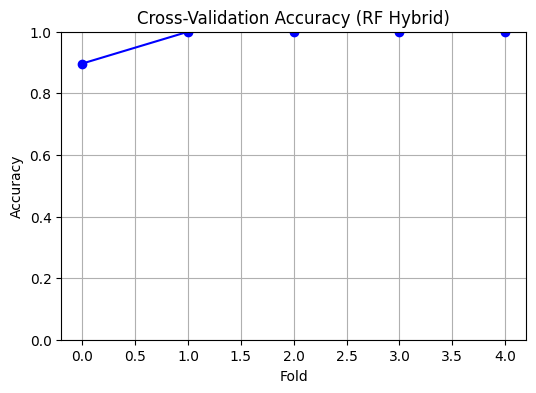

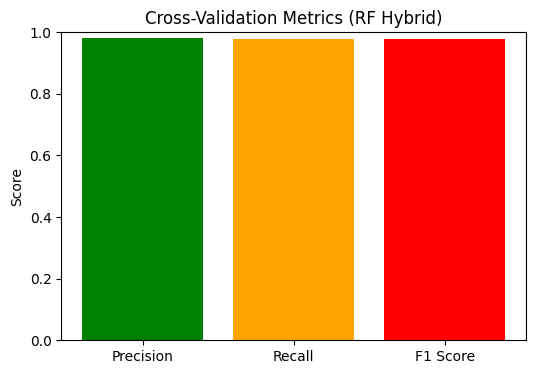

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

# ==============================
# PIPELINE (NO DATA LEAKAGE)
# ==============================
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=15)),
    ('rf', RandomForestClassifier(
        n_estimators=120,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])

# ==============================
# CROSS VALIDATION ACCURACY
# ==============================
scores = cross_val_score(pipeline, X_train, y_train, cv=5)

print("Cross-validation Accuracy:", scores.mean())

# ==============================
# CROSS VALIDATION PREDICTIONS
# ==============================
y_cv_pred = cross_val_predict(pipeline, X_train, y_train, cv=5)

# ==============================
# METRICS
# ==============================
precision = precision_score(y_train, y_cv_pred, average='weighted')
recall = recall_score(y_train, y_cv_pred, average='weighted')
f1 = f1_score(y_train, y_cv_pred, average='weighted')

print("\nCROSS-VALIDATION METRICS\n")
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# ==============================
# GRAPH 1: CV ACCURACY PER FOLD
# ==============================
plt.figure(figsize=(6,4))
plt.plot(scores, marker='o', color='blue')
plt.title("Cross-Validation Accuracy (RF Hybrid)")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.grid()
plt.show()

# ==============================
# GRAPH 2: METRICS BAR GRAPH
# ==============================
metrics = [precision, recall, f1]
labels = ["Precision", "Recall", "F1 Score"]

plt.figure(figsize=(6,4))
plt.bar(labels, metrics, color=['green','orange','red'])
plt.ylim(0,1)
plt.title("Cross-Validation Metrics (RF Hybrid)")
plt.ylabel("Score")
plt.show()